In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score
)
from sklearn.calibration import calibration_curve

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
file_path = "day18_optimized_fraud_results.csv"

data = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

data.head()

Dataset loaded successfully!
Shape: (8648, 11)

Columns:
['actual_fraud', 'xgboost_score', 'isolation_score', 'autoencoder_score', 'hybrid_score', 'risk_score', 'risk_level', 'predicted_fraud', 'optimized_prediction', 'fraud_category', 'recommended_action']


,actual_fraud,xgboost_score,isolation_score,autoencoder_score,hybrid_score,risk_score,risk_level,predicted_fraud,optimized_prediction,fraud_category,recommended_action
0,0,0.197072,0.307266,0.001963,0.175844,17.58,Low,0,0,Normal,Approve
1,0,0.292918,0.519151,0.005707,0.277673,27.77,Low,0,0,Normal,Approve
2,0,0.227300,0.096386,0.002740,0.138432,13.84,Low,0,0,Normal,Approve
3,0,0.640401,0.191060,0.006936,0.369700,36.97,Medium,0,0,Suspicious,Monitor
4,0,0.307999,0.090222,0.000996,0.176804,17.68,Low,0,0,Normal,Approve


In [3]:
possible_target_columns = [
    "actual_fraud",
    "is_fraud",
    "fraud",
    "fraud_label",
    "label",
    "Class",
    "target"
]

target_column = next(
    (
        column for column in possible_target_columns
        if column in data.columns
    ),
    None
)

if target_column is None:
    raise ValueError(
        "Fraud label column was not found. "
        "Available columns are: "
        + str(data.columns.tolist())
    )

data["actual_fraud"] = pd.to_numeric(
    data[target_column],
    errors="coerce"
)

data = data.dropna(subset=["actual_fraud"]).copy()
data["actual_fraud"] = data["actual_fraud"].astype(int)

print("Target column used:", target_column)
print(data["actual_fraud"].value_counts())

Target column used: actual_fraud
actual_fraud
0    8499
1     149
Name: count, dtype: int64


In [4]:
possible_score_columns = [
    "hybrid_score",
    "risk_score",
    "xgboost_score",
    "fraud_probability",
    "model_probability"
]

score_column = next(
    (
        column for column in possible_score_columns
        if column in data.columns
    ),
    None
)

if score_column is None:
    raise ValueError(
        "Model score column was not found. "
        "Available columns are: "
        + str(data.columns.tolist())
    )

data["uncalibrated_probability"] = pd.to_numeric(
    data[score_column],
    errors="coerce"
)

data = data.dropna(
    subset=["uncalibrated_probability"]
).copy()

if data["uncalibrated_probability"].max() > 1:
    data["uncalibrated_probability"] = (
        data["uncalibrated_probability"] / 100
    )

data["uncalibrated_probability"] = (
    data["uncalibrated_probability"].clip(0, 1)
)

print("Score column used:", score_column)

data[
    ["actual_fraud", "uncalibrated_probability"]
].head()

Score column used: hybrid_score


,actual_fraud,uncalibrated_probability
0,0,0.175844
1,0,0.277673
2,0,0.138432
3,0,0.369700
4,0,0.176804


In [5]:
X = data[["uncalibrated_probability"]]
y = data["actual_fraud"]

calibration_data, reliability_data = train_test_split(
    data,
    test_size=0.50,
    random_state=42,
    stratify=y
)

print("Calibration rows:", len(calibration_data))
print("Reliability analysis rows:", len(reliability_data))

Calibration rows: 4324
Reliability analysis rows: 4324


In [6]:
calibration_model = LogisticRegression(
    random_state=42
)

calibration_model.fit(
    calibration_data[["uncalibrated_probability"]],
    calibration_data["actual_fraud"]
)

print("Calibration model trained successfully!")

Calibration model trained successfully!


In [7]:
reliability_data = reliability_data.copy()

reliability_data["calibrated_probability"] = (
    calibration_model.predict_proba(
        reliability_data[["uncalibrated_probability"]]
    )[:, 1]
)

reliability_data[
    [
        "actual_fraud",
        "uncalibrated_probability",
        "calibrated_probability"
    ]
].head()

,actual_fraud,uncalibrated_probability,calibrated_probability
6263,0,0.394857,0.027773
4125,0,0.238688,0.016054
5724,0,0.170040,0.012595
6906,0,0.252745,0.016870
5365,0,0.225391,0.015318


In [8]:
y_reliability = reliability_data["actual_fraud"]

uncalibrated_brier = brier_score_loss(
    y_reliability,
    reliability_data["uncalibrated_probability"]
)

calibrated_brier = brier_score_loss(
    y_reliability,
    reliability_data["calibrated_probability"]
)

uncalibrated_log_loss = log_loss(
    y_reliability,
    reliability_data["uncalibrated_probability"],
    labels=[0, 1]
)

calibrated_log_loss = log_loss(
    y_reliability,
    reliability_data["calibrated_probability"],
    labels=[0, 1]
)

uncalibrated_auc = roc_auc_score(
    y_reliability,
    reliability_data["uncalibrated_probability"]
)

calibrated_auc = roc_auc_score(
    y_reliability,
    reliability_data["calibrated_probability"]
)

calibration_results = pd.DataFrame({
    "model": [
        "Before Calibration",
        "After Calibration"
    ],
    "brier_score": [
        uncalibrated_brier,
        calibrated_brier
    ],
    "log_loss": [
        uncalibrated_log_loss,
        calibrated_log_loss
    ],
    "roc_auc": [
        uncalibrated_auc,
        calibrated_auc
    ]
})

calibration_results.round(4)

,model,brier_score,log_loss,roc_auc
0,Before Calibration,0.0748,0.3044,0.5955
1,After Calibration,0.0168,0.0851,0.5955


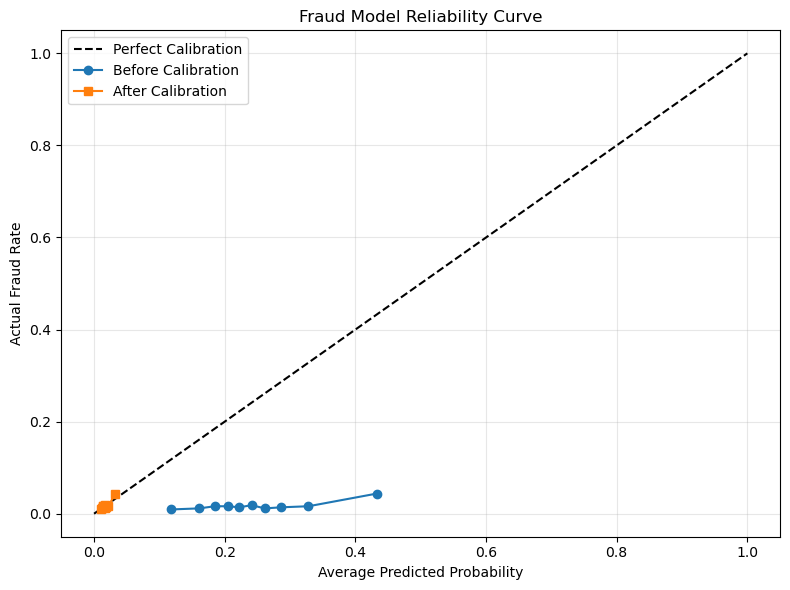

In [9]:
uncalibrated_actual, uncalibrated_predicted = (
    calibration_curve(
        y_reliability,
        reliability_data["uncalibrated_probability"],
        n_bins=10,
        strategy="quantile"
    )
)

calibrated_actual, calibrated_predicted = (
    calibration_curve(
        y_reliability,
        reliability_data["calibrated_probability"],
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Perfect Calibration"
)

plt.plot(
    uncalibrated_predicted,
    uncalibrated_actual,
    marker="o",
    label="Before Calibration"
)

plt.plot(
    calibrated_predicted,
    calibrated_actual,
    marker="s",
    label="After Calibration"
)

plt.xlabel("Average Predicted Probability")
plt.ylabel("Actual Fraud Rate")
plt.title("Fraud Model Reliability Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
reliability_data["probability_bin"] = pd.qcut(
    reliability_data["calibrated_probability"],
    q=10,
    duplicates="drop"
)

reliability_table = (
    reliability_data
    .groupby(
        "probability_bin",
        observed=False
    )
    .agg(
        total_transactions=(
            "actual_fraud",
            "count"
        ),
        average_predicted_probability=(
            "calibrated_probability",
            "mean"
        ),
        actual_fraud_rate=(
            "actual_fraud",
            "mean"
        ),
        actual_fraud_cases=(
            "actual_fraud",
            "sum"
        )
    )
    .reset_index()
)

reliability_table.round(4)

,probability_bin,total_transactions,average_predicted_probability,actual_fraud_rate,actual_fraud_cases
0,"(0.00681, 0.0116]",433,0.0105,0.0092,4
1,"(0.0116, 0.0128]",432,0.0122,0.0116,5
2,"(0.0128, 0.0138]",432,0.0133,0.0162,7
3,"(0.0138, 0.0147]",433,0.0143,0.0162,7
4,"(0.0147, 0.0156]",432,0.0152,0.0139,6
5,"(0.0156, 0.0168]",432,0.0162,0.0185,8
6,"(0.0168, 0.0181]",433,0.0174,0.0115,5
7,"(0.0181, 0.0201]",432,0.0190,0.0139,6
8,"(0.0201, 0.0251]",432,0.0220,0.0162,7
9,"(0.0251, 0.0575]",433,0.0322,0.0439,19


In [11]:
reliability_table["calibration_gap"] = abs(
    reliability_table["average_predicted_probability"]
    - reliability_table["actual_fraud_rate"]
)

valid_bins = reliability_table[
    reliability_table["total_transactions"] > 0
].copy()

expected_calibration_error = np.average(
    valid_bins["calibration_gap"],
    weights=valid_bins["total_transactions"]
)

print(
    "Expected Calibration Error:",
    round(expected_calibration_error, 4)
)

Expected Calibration Error: 0.0039


In [12]:
reliability_data["calibrated_risk_score"] = (
    reliability_data["calibrated_probability"] * 100
).round(2)

reliability_data["calibrated_risk_level"] = pd.cut(
    reliability_data["calibrated_risk_score"],
    bins=[-1, 30, 60, 80, 100],
    labels=[
        "Low",
        "Medium",
        "High",
        "Critical"
    ]
)

reliability_data[
    [
        "actual_fraud",
        "uncalibrated_probability",
        "calibrated_probability",
        "calibrated_risk_score",
        "calibrated_risk_level"
    ]
].head()

,actual_fraud,uncalibrated_probability,calibrated_probability,calibrated_risk_score,calibrated_risk_level
6263,0,0.394857,0.027773,2.78,Low
4125,0,0.238688,0.016054,1.61,Low
5724,0,0.170040,0.012595,1.26,Low
6906,0,0.252745,0.016870,1.69,Low
5365,0,0.225391,0.015318,1.53,Low


In [13]:
reliability_data.to_csv(
    "calibrated_fraud_predictions.csv",
    index=False
)

calibration_results.to_csv(
    "model_calibration_metrics.csv",
    index=False
)

reliability_table.to_csv(
    "probability_reliability_table.csv",
    index=False
)

joblib.dump(
    calibration_model,
    "hybrid_calibration_model.pkl"
)

print("Files saved successfully:")
print("1. calibrated_fraud_predictions.csv")
print("2. model_calibration_metrics.csv")
print("3. probability_reliability_table.csv")
print("4. hybrid_calibration_model.pkl")

Files saved successfully:
1. calibrated_fraud_predictions.csv
2. model_calibration_metrics.csv
3. probability_reliability_table.csv
4. hybrid_calibration_model.pkl
